# Practice — Pandas + NumPy (Iris)

10 связанных упражнений на датасете **Iris** (классический ботанический датасет: длина и ширина чашелистиков и лепестков для 150 цветков трёх видов). Идём по цепочке: загрузка → EDA → чистка → фичи → numpy.

Формат каждого упражнения: **Что делаем / Вход / Ожидаемый выход**.

Стаб для кода: `# напишите Ваш код в этой ячейке`.

Если застрял — посмотри `00_pandas_numpy_primer_solution.ipynb`.


## О датасете

Используем **Iris** из `sklearn.datasets.load_iris()` — 150 цветков трёх видов (`setosa`, `versicolor`, `virginica`). Для каждого цветка измерены 4 признака. Это один из самых известных датасетов в ML — на нём показывают всё от EDA до классификации.

| Колонка | Тип | Описание |
|---|---|---|
| `sepal_length` | float | Длина чашелистика, см |
| `sepal_width` | float | Ширина чашелистика, см |
| `petal_length` | float | Длина лепестка, см |
| `petal_width` | float | Ширина лепестка, см |
| `species` | category | Вид: setosa / versicolor / virginica |

Размер: 150 строк × 5 колонок.


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)':  'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)':  'petal_width',
})
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.shape)


(150, 6)


## Упражнение 1 — Первый взгляд

**Что делаем:** выведи первые 8 строк датасета и его форму.

**Вход:** `df`.

**Ожидаемый выход:** строка вида `(150, 5)` и таблица 8×5.


In [3]:
# твой код
print(df.shape)
print(df.head(8))

(150, 6)
   sepal_length  sepal_width  petal_length  petal_width  target species
0           5.1          3.5           1.4          0.2       0  setosa
1           4.9          3.0           1.4          0.2       0  setosa
2           4.7          3.2           1.3          0.2       0  setosa
3           4.6          3.1           1.5          0.2       0  setosa
4           5.0          3.6           1.4          0.2       0  setosa
5           5.4          3.9           1.7          0.4       0  setosa
6           4.6          3.4           1.4          0.3       0  setosa
7           5.0          3.4           1.5          0.2       0  setosa


## Упражнение 2 — Сводная статистика — медианы

**Что делаем:** через `describe()` посчитай статистику и выведи только медиану (50-й перцентиль) каждой числовой колонки. Округли до 2 знаков.

**Вход:** `df`.

**Ожидаемый выход:** Series длины 4 (sepal_length, sepal_width, petal_length, petal_width).


In [11]:
# твой код
print(df.describe().iloc[5, :4])

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
Name: 50%, dtype: float64


## Упражнение 3 — Проверка на NaN и дубли

**Что делаем:** в одной ячейке выведи (1) сколько NaN в каждой колонке, (2) сколько строк-дубликатов в датасете.

**Вход:** `df`.

**Ожидаемый выход:** Series с нулями (NaN) и число дубликатов (в Iris бывают совпадающие строки — нормально).


In [16]:
# твой код
print(df.isna().sum())
print("Количество дубликатов:", df.duplicated().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64
Количество дубликатов: 1


## Упражнение 4 — Фильтрация: только крупные цветки

**Что делаем:** оставь только строки, где `petal_length > 4` и `petal_width > 1.2`. Сохрани в `big_flowers`. Выведи `len(big_flowers)` и распределение по видам (`value_counts`).

**Вход:** `df`.

**Ожидаемый выход:** число (около 80-100) и распределение по 2-3 видам.


In [18]:
# твой код
big_flowers = df[(df['petal_length'] > 4) & (df['petal_width'] > 1.2)]
print("Всего больших цветков:", len(big_flowers))
print("Распределение по видам:")
print(big_flowers.value_counts('species'))


Всего больших цветков: 80
Распределение по видам:
species
virginica     50
versicolor    30
setosa         0
Name: count, dtype: int64


## Упражнение 5 — Выбросы по IQR в `sepal_width`

**Что делаем:** найди выбросы в колонке `sepal_width` по правилу IQR (вне `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`). Выведи количество и сами строки-выбросы.

**Вход:** `df`.

**Ожидаемый выход:** число (несколько штук) и таблица с этими строками.


In [21]:
# твой код
q1, q3 = df['sepal_width'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = df[(df['sepal_width'] < low) | (df['sepal_width'] > high)]
print("Количество выбросов по ширине чашелистика:", len(out))
out

Количество выбросов по ширине чашелистика: 4


,sepal_length,sepal_width,petal_length,petal_width,target,species
15,5.7,4.4,1.5,0.4,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
33,5.5,4.2,1.4,0.2,0,setosa
60,5.0,2.0,3.5,1.0,1,versicolor


## Упражнение 6 — График распределения `petal_length`

**Что делаем:** построй гистограмму `petal_length` с 20 бинами через `df['petal_length'].hist()` или `sns.histplot()`. Заголовок: «Распределение длины лепестка». Подпиши оси.

**Вход:** `df`.

**Ожидаемый выход:** график-гистограмма (видно характерное **бимодальное** распределение — setosa отделён от versicolor+virginica).


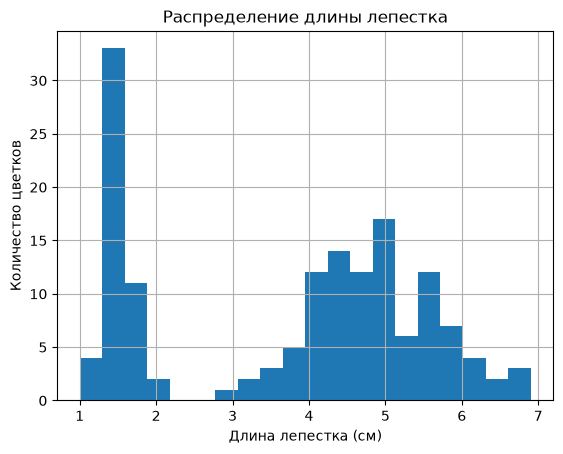

In [25]:
# твой код
ax = df['petal_length'].hist(bins=20)

ax.set_title('Распределение длины лепестка')
ax.set_xlabel('Длина лепестка (см)')
ax.set_ylabel('Количество цветков')

plt.show()

## Упражнение 7 — Scatter + интерпретация

**Что делаем:** построй scatterplot `petal_length` vs `petal_width`, раскрась точки по `species` (через `sns.scatterplot(..., hue='species')`). По графику глазами ответь в комментарии (`# ответ: ...`): какой вид легко отделяется от остальных?

**Вход:** `df`.

**Ожидаемый выход:** график + строка-комментарий с ответом.


<Axes: xlabel='petal_length', ylabel='petal_width'>

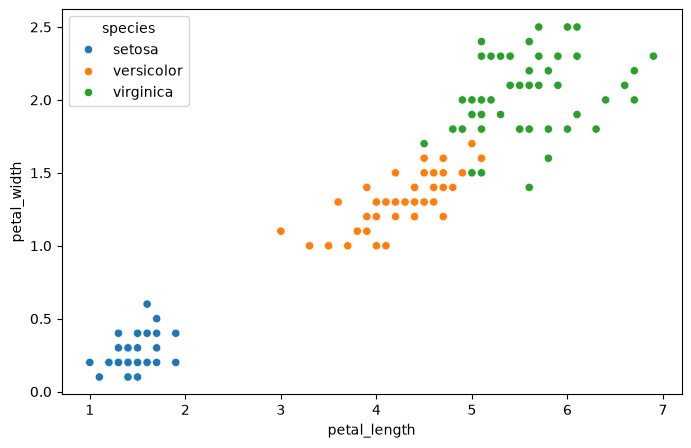

In [27]:
# твой код
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=ax)
# ответ: Setosa

## Упражнение 8 — Pandas → numpy

**Что делаем:** преврати `df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]` в numpy-массив `X`, а коды видов (`iris.target`) — в numpy-массив `y`. Выведи `X.shape, y.shape, X.dtype`.

**Вход:** `df`, `iris`.

**Ожидаемый выход:** `(150, 4) (150,) float64`.


In [30]:
# твой код
X = np.array(df[['petal_length', 'sepal_length', 'petal_width', 'sepal_width']])
y = np.array(df['species'])
X.shape, y.shape, X.dtype

((150, 4), (150,), dtype('float64'))

## Упражнение 9 — Векторизация и broadcasting

**Что делаем:** посчитай нормализованную версию `X`: вычти среднее по колонкам и подели на стандартное отклонение по колонкам (`(X - X.mean(0)) / X.std(0)`). Сохрани в `X_norm`. Проверь, что среднее каждой колонки ≈0, std ≈1.

**Вход:** `X` из упр. 8.

**Ожидаемый выход:** `X_norm.mean(0).round(6)` ≈ `[0, 0, 0, 0]`, `X_norm.std(0).round(6)` ≈ `[1, 1, 1, 1]`.


In [31]:
# твой код
X_norm = (X - X.mean(0)) / X.std(0)
X_norm.mean(0).round(6), X_norm.std(0).round(6)

(array([-0., -0., -0., -0.]), array([1., 1., 1., 1.]))

## Упражнение 10 — Бизнес-вывод

**Что делаем:** посчитай среднюю `petal_length` отдельно по каждому виду (`groupby('species')['petal_length'].mean()`). Выведи и в комментарии напиши вывод (`# вывод: ...`): какой вид имеет самый длинный лепесток в среднем и насколько разница большая.

**Вход:** `df`.

**Ожидаемый выход:** Series длины 3 и строка-вывод.


In [32]:
# твой код
# вывод: ...
df.groupby('species')['petal_length'].agg(['mean', 'std']).round(2)

,mean,std
species,,
setosa,1.46,0.17
versicolor,4.26,0.47
virginica,5.55,0.55


Самый длинный лепесток в среднем у virginica, разница с setosa и versicolor существенная (несколько см).